Processing: C:\Python\Personal\mcculloch-processors\cad\data\3YBP_VD-2027-01-04.dxf
  Interpolating 1029174 points onto grid...
Processing: C:\Python\Personal\mcculloch-processors\cad\data\3YBP_VD-2027-03-01.dxf
  Interpolating 1004587 points onto grid...


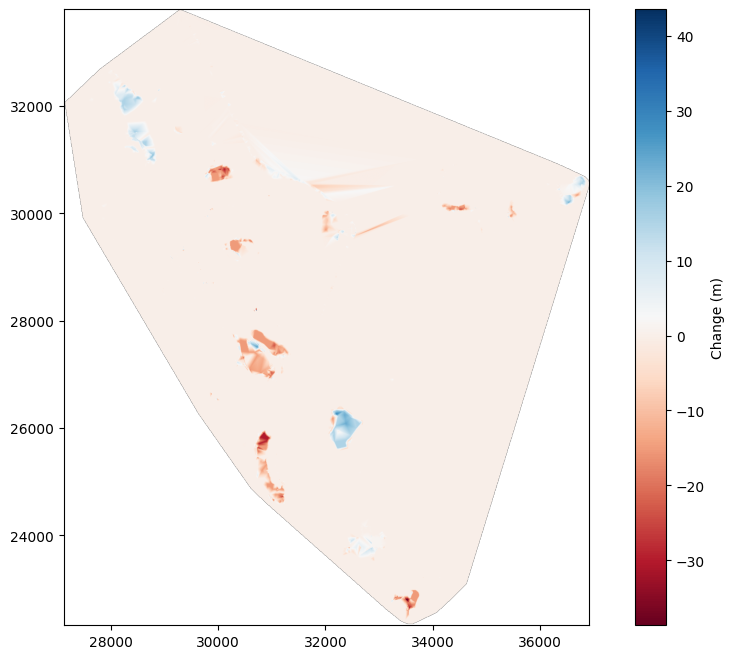

In [ ]:
import ezdxf
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

def get_combined_bounds(dxf_paths):
    """Scan of vertices to find approximate site bounds."""
    x_mins, y_mins, x_maxs, y_maxs = [], [], [], []
    print("Scanning DXF vertices for bounds...")
    
    for path in dxf_paths:
        doc = ezdxf.readfile(path)
        msp = doc.modelspace()
        
        # only query vertices of primary surface entities
        for entity in msp.query('3DFACE MESH POLYLINE'):
            if entity.dxftype() == '3DFACE':
                pts = [entity.dxf.vtx0, entity.dxf.vtx1, entity.dxf.vtx2, entity.dxf.vtx3]
            elif entity.dxftype() == 'MESH':
                pts = entity.vertices
            elif entity.dxftype() == 'POLYLINE':
                pts = [v.dxf.location for v in entity.vertices]
            else: continue
            
            # update local bounds for this file
            arr = np.array(pts)
            if arr.size > 0:
                x_mins.append(arr[:, 0].min())
                y_mins.append(arr[:, 1].min())
                x_maxs.append(arr[:, 0].max())
                y_maxs.append(arr[:, 1].max())

    # add 10 unit buffer
    return (min(x_mins)-10, max(x_maxs)+10, min(y_mins)-10, max(y_maxs)+10)

def dxf_to_grid(dxf_path, bounds_info):
    """Single-process extraction of DXF data and interpolation onto a grid."""
    x_min, x_max, y_min, y_max, pixel_size = bounds_info
    
    # create grid
    xi = np.arange(x_min, x_max, pixel_size)
    yi = np.arange(y_min, y_max, pixel_size)
    X_local, Y_local = np.meshgrid(xi, yi)
    
    print(f"Processing: {dxf_path}")
    doc = ezdxf.readfile(dxf_path)
    msp = doc.modelspace()
    points = []
    
    # extract vertices
    for entity in msp.query('3DFACE MESH POLYLINE'):
        if entity.dxftype() == '3DFACE':
            points.extend([entity.dxf.vtx0, entity.dxf.vtx1, entity.dxf.vtx2, entity.dxf.vtx3])
        elif entity.dxftype() == 'MESH':
            points.extend(entity.vertices)
        elif entity.dxftype() == 'POLYLINE' and (entity.is_polyface_mesh or entity.is_polygon_mesh):
            for v in entity.vertices: points.append(v.dxf.location)
            
    if not points:
        return np.full(X_local.shape, np.nan)
        
    pts = np.unique(np.array(points), axis=0)
    
    # linear interpolate dxf data onto grid
    print(f"  Interpolating {len(pts)} points onto grid...")
    z_grid = griddata((pts[:,0], pts[:,1]), pts[:,2], (X_local, Y_local), method='linear')
    
    # clear points from memory before returning
    del points
    del pts
    return z_grid

if __name__ == '__main__':
    dxf_jan = r"C:\Python\Personal\mcculloch-processors\cad\data\3YBP_VD-2027-01-04.dxf"
    dxf_mar = r"C:\Python\Personal\mcculloch-processors\cad\data\3YBP_VD-2027-03-01.dxf"

    # use bounds from get_combined_bounds result
    pixel_size = 10
    bounds_info = (x_min, x_max, y_min, y_max, pixel_size) 

    # process one at a time
    Z_jan = dxf_to_grid(dxf_jan, bounds_info)
    Z_mar = dxf_to_grid(dxf_mar, bounds_info)

    # calculate elevation difference
    diff = Z_mar - Z_jan
    
    # visualize
    plt.figure(figsize=(12, 8))
    plt.imshow(diff, extent=(x_min, x_max, y_min, y_max), origin='lower', cmap='RdBu')
    plt.colorbar(label='Elevation Change: March 2027 vs. January 2027 (m)')
    plt.show()